<a href="https://colab.research.google.com/github/Ayon150/BDSET_EXAM/blob/main/Job_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Bidirectional
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
from google.colab import files
import pandas as pd

print("Please select the dataset file from your local device:")
uploaded = files.upload()

Please select the dataset file from your local device:


Saving Job_3_Resource_sentiment.csv to Job_3_Resource_sentiment.csv


In [4]:
df = pd.read_csv("Job_3_Resource_sentiment.csv")
print(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [5]:
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [6]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [7]:
df.rename(columns={'Positive': 'sentiment'}, inplace=True)
df.rename(columns={'im getting on borderlands and i will murder you all ,': 'text'}, inplace=True)


In [8]:
df.columns


Index(['2401', 'Borderlands', 'sentiment', 'text'], dtype='object')

In [9]:
df = df[['text', 'sentiment']]

In [10]:
df.sample(5)

,text,sentiment
40748,If we ever get Battlefield 6 I do hope it's as...,Neutral
17220,What a pity.,Negative
4273,The Worst Way to Die in,Negative
16275,The whole professional comedy dota 2 scene is ...,Positive
34979,Microsoft Forecasts a Rise in Hybrid Working a...,Neutral


In [11]:
df.shape

(74681, 2)

In [12]:
df.isnull().sum()

,0
text,686
sentiment,0


In [13]:
print(df['sentiment'].value_counts())

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [14]:
# Drop missing values
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

,0
text,0
sentiment,0


In [16]:
# Convert text to string
df['text'] = df['text'].astype(str)


In [17]:
df['text']

,text
0,I am coming to the borders and I will kill you...
1,im getting on borderlands and i will kill you ...
2,im coming on borderlands and i will murder you...
3,im getting on borderlands 2 and i will murder ...
4,im getting into borderlands and i can murder y...
...,...
74676,Just realized that the Windows partition of my...
74677,Just realized that my Mac window partition is ...
74678,Just realized the windows partition of my Mac ...
74679,Just realized between the windows partition of...


In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

In [19]:
df['text']

,text
0,i am coming to the borders and i will kill you...
1,im getting on borderlands and i will kill you all
2,im coming on borderlands and i will murder you...
3,im getting on borderlands and i will murder y...
4,im getting into borderlands and i can murder y...
...,...
74676,just realized that the windows partition of my...
74677,just realized that my mac window partition is ...
74678,just realized the windows partition of my mac ...
74679,just realized between the windows partition of...


In [20]:
encoder = LabelEncoder()
df['sentiment_encoded'] = encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, c in enumerate(encoder.classes_):
    print(i, "->", c)

Label mapping:
0 -> Irrelevant
1 -> Negative
2 -> Neutral
3 -> Positive


In [21]:
max_words = 20000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df['text']),
    maxlen=max_length,
    padding='post'
)

y = df['sentiment_encoded'].values


In [22]:
y

array([3, 3, 3, ..., 3, 3, 3])

In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Train: (51796, 100)
Validation: (11099, 100)
Test: (11100, 100)


In [24]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4368619618286729), 1: np.float64(0.8274121405750798), 2: np.float64(1.0215367623856106), 3: np.float64(0.8956287176649605)}


In [25]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(max_words, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,659,332 (10.14 MB)

 Trainable params: 2,659,332 (10.14 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
early = EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early],
    class_weight=class_weights_dict
)

Epoch 1/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.6362 - loss: 0.9041 - val_accuracy: 0.7602 - val_loss: 0.6433
Epoch 2/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8352 - loss: 0.4511 - val_accuracy: 0.8263 - val_loss: 0.4750
Epoch 3/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8893 - loss: 0.3056 - val_accuracy: 0.8436 - val_loss: 0.4473
Epoch 4/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step - accuracy: 0.9106 - loss: 0.2390 - val_accuracy: 0.8540 - val_loss: 0.4454
Epoch 5/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9267 - loss: 0.1962 - val_accuracy: 0.8595 - val_loss: 0.4601
Epoch 6/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9357 - loss: 0.1688 - val_accuracy: 0.8639 - val_loss: 0.4525
Epoch 7/20
1619/1619 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9420 - loss: 0.1517 - val_accuracy: 0.8649 - val_loss: 0.4694


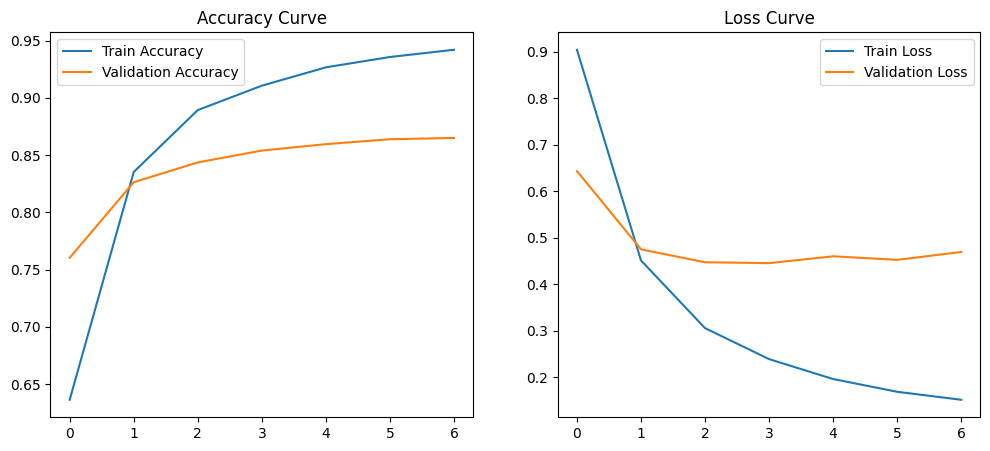

In [28]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")

plt.show()


In [29]:
if history.history['accuracy'][-1] > history.history['val_accuracy'][-1]:
    print("⚠️ Possible Overfitting detected")
else:
    print("✅ Model is generalizing well")

⚠️ Possible Overfitting detected


In [30]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Accuracy: 0.8594594594594595
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1932
           1       0.88      0.88      0.88      3354
           2       0.83      0.86      0.85      2716
           3       0.87      0.86      0.86      3098

    accuracy                           0.86     11100
   macro avg       0.86      0.86      0.86     11100
weighted avg       0.86      0.86      0.86     11100



In [31]:
model.save("sentiment_analysis_model.keras")
print("✅ Model saved successfully")

✅ Model saved successfully


In [32]:
def predict_sentiment(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100, padding='post')
    probs = model.predict(pad)[0]
    return encoder.classes_[probs.argmax()], probs

texts = [
    "I love this game so much",
    "This game is terrible",
    "I have no opinion",
    "What is this even about?"
]

for t in texts:
    pred, prob = predict_sentiment(t)
    print(t, "->", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
I love this game so much -> Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
This game is terrible -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
I have no opinion -> Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
What is this even about? -> Negative
